# 🌀 🌋 02. Data Ingestion & Exploratory Data Analysis (EDA): Cyclones, Volcanoes & Regional Risk (Spain)

## 📌 Notebook Objectives
This notebook handles data collection, cleaning, missing value documentation, and initial exploratory analysis for **Person 2's** scope:
1. **IBTrACS (NOAA):** Global historical dataset for tropical cyclones and storm tracks.
2. **Global Volcanism Program / NOAA Hazards:** Global catalogue of active volcanoes and historical eruptions.
3. **Península Ibérica & Canary Islands (IGN/USGS):** Regionally bounded seismic and volcanic hazard data for Spanish territory.

---

## 💡 Methodological Decisions & Trade-offs

### 1. Data Source Selection
* **IBTrACS:** The gold standard for global storm track reconstruction, enabling wind and pressure risk modeling.
* **NOAA Hazel API:** Delivers robust geographic coordinates, elevation, and volcano classification worldwide.
* **Geographic Bounding (Spain / Canary Islands):** To accurately capture regional risk (focusing on Canary Islands and Mainland Spain), we restrict event queries to a precise bounding box (`Lat: 27°N to 44°N`, `Lon: -19°W to 5°E`).

In [1]:
# ======================================================
# 02. EDA - CYCLONES, VOLCANOES & SPAIN/CANARIES (Person 2)
# ======================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import os

# Visual configuration
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Initialize DataFrames to prevent NameError exceptions
df_ciclones_raw = pd.DataFrame()
df_volcanes_raw = pd.DataFrame()
df_espana_raw = pd.DataFrame()

# ------------------------------------------------------
# 1. DATA SOURCES INGESTION
# ------------------------------------------------------

# 1.1 IBTrACS Cyclones  (NOAA)
RAW_PATH = "../data/raw"

IBTRACS_FILE = os.path.join(
    RAW_PATH,
    "ibtracs_all_list_v04r01.csv"
)
# 1.2 Global Volcanoes URL (NOAA Hazel Hazard Service API)
url_volcanes_api = "https://www.ngdc.noaa.gov/hazel/hazard-service/api/v1/volcanoes"

# 1.3 Spain & Canary Islands (IGN Local CSV)
IGN_FILE = os.path.join(
    RAW_PATH,
    "ign_earthquakes_1900_present.csv"
)


# --- A. Ingest Cyclones ---
print("📥 [1/3] Downloading & ingesting Cyclones (IBTrACS)...")
try:
     df_ciclones_raw = pd.read_csv(
        IBTRACS_FILE,
        skiprows=[1],
        low_memory=False
    )

except Exception as e:
    print(f"❌ Error loading cyclones: {e}")

# --- B. Ingest Volcanoes ---
print("📥 [2/3] Downloading & ingesting Global Volcanoes...")
try:
    res_volcanes = requests.get(url_volcanes_api, timeout=15)
    if res_volcanes.status_code == 200:
        df_volcanes_raw = pd.DataFrame(res_volcanes.json()['items'])
except Exception as e:
    print(f"❌ Error downloading volcanoes: {e}")

# --- C. Ingest Spain & Canary Islands Events (IGN) ---
print("📥 [3/3] Loading Spain & Canary Islands events...")
try:
    df_espana_raw = pd.read_csv(
        IGN_FILE,
        encoding="latin1",
        sep=";",
        low_memory=False
    )
    
    df_espana_raw.columns = [c.lstrip() for c in df_espana_raw.columns]
    
    df_espana_raw.rename(
        columns={
            "Localizaci?n": "place",
            "Localización": "place"
        },
        inplace=True
    )

except Exception as e:
    print(f"❌ Error loading IGN dataset: {e}")
 

print("\n✨ Ingestion Summary:")
print(f" 🌀 Cyclones (IBTrACS):      {df_ciclones_raw.shape[0]} rows | {df_ciclones_raw.shape[1]} columns")
print(f" 🌋 Global Volcanoes:        {df_volcanes_raw.shape[0]} rows | {df_volcanes_raw.shape[1]} columns")
print(f" 🇪🇸 Spain / Canary Islands: {df_espana_raw.shape[0]} rows | {df_espana_raw.shape[1]} columns")

📥 [1/3] Downloading & ingesting Cyclones (IBTrACS)...
📥 [2/3] Downloading & ingesting Global Volcanoes...
📥 [3/3] Loading Spain & Canary Islands events...

✨ Ingestion Summary:
 🌀 Cyclones (IBTrACS):      724970 rows | 10 columns
 🌋 Global Volcanoes:        200 rows | 43 columns
 🇪🇸 Spain / Canary Islands: 203823 rows | 10 columns


In [9]:
# ------------------------------------------------------
# 2. FEATURE SELECTION AND INITIAL CLEANING
# ------------------------------------------------------


# --- A. Cyclones (IBTrACS) ---
cols_ciclones = [
    'SID',
    'ISO_TIME',
    'LAT',
    'LON',
    'WMO_WIND',
    'WMO_PRES',
    'BASIN'
]


df_ciclones = df_ciclones_raw[cols_ciclones].copy()


# Datatype casting
df_ciclones['LAT'] = pd.to_numeric(df_ciclones['LAT'], errors='coerce')
df_ciclones['LON'] = pd.to_numeric(df_ciclones['LON'], errors='coerce')
df_ciclones['WMO_WIND'] = pd.to_numeric(df_ciclones['WMO_WIND'], errors='coerce')


df_ciclones['WMO_PRES'] = pd.to_numeric(
    df_ciclones['WMO_PRES'],
    errors='coerce'
)


df_ciclones['ISO_TIME'] = pd.to_datetime(df_ciclones['ISO_TIME'], errors='coerce')


df_ciclones = df_ciclones[
    df_ciclones["ISO_TIME"].dt.year >= 1900
].copy()



# --- B. Global Volcanoes ---
cols_volcanes = [
    'name',
    'latitude',
    'longitude',
    'elevation',
    'country'
]


df_volcanes = df_volcanes_raw[cols_volcanes].copy()


cols_volcanes_existentes = [
    c for c in cols_volcanes 
    if c in df_volcanes_raw.columns
]


df_volcanes = df_volcanes_raw[
    cols_volcanes_existentes
].copy()


# --- C. Spain / Canary Islands ---
df_espana = df_espana_raw.copy()


# Fix IGN latitude scale (esta columna SI parece estar afectada solo
# parcialmente / de forma uniforme; se mantiene igual que el original)
df_espana["Latitud"] = df_espana["Latitud"] / 10


print("Antes de corregir Longitud:")
print(df_espana[["Latitud", "Longitud"]].describe())


# Fix IGN longitude scale
# BUG ORIGINAL: la mascara `Longitud < -100` solo corregia una parte de
# los registros, dejando el resto (p.ej. valores entre -100 y el rango
# valido) igual de mal escalados. Los percentiles de la columna completa
# (min -200, max 60, mediana -42) muestran que el error de escala x10
# afecta a PRACTICAMENTE TODA la columna, no a un subconjunto -- por eso
# se corrige sin condicion, igual que se hace con Latitud.
df_espana["Longitud"] = df_espana["Longitud"] / 10


print("\nDespues de corregir Longitud:")
print(df_espana[["Latitud", "Longitud"]].describe())



df_espana["Fecha"] = pd.to_datetime(
    df_espana["Fecha"],
    dayfirst=True,
    errors="coerce"
)


df_espana["timestamp"] = pd.to_datetime(
    df_espana["Fecha"].astype(str) + " " + df_espana["Hora"].astype(str),
    errors="coerce"
)



df_espana = df_espana[
    df_espana["Fecha"].dt.year >= 1900
].copy()


# ------------------------------------------------------
# Standardise column names
# ------------------------------------------------------


df_ciclones = df_ciclones.rename(columns={
    "LAT": "lat",
    "LON": "lon",
    "ISO_TIME": "timestamp",
    "WMO_WIND": "wind",
    "WMO_PRES": "pressure",
    "SID": "event_id",
    "BASIN": "basin"
})


df_volcanes = df_volcanes.rename(columns={
    "latitude": "lat",
    "longitude": "lon",
    "name": "place"
})


df_espana = df_espana.rename(columns={
    "Latitud": "lat",
    "Longitud": "lon",
    "Mag.": "magnitude",
    "Tipo Mag.": "mag_type",
    "Prof. (Km)": "depth_km",
    "Evento": "event_id"
})


# Convert magnitude to numeric
df_espana["magnitude"] = pd.to_numeric(
    df_espana["magnitude"].astype(str).str.strip(),
    errors="coerce"
)


# Geographic validation: Spain & Canary Islands bounding box
df_espana = df_espana[
    (df_espana["lat"].between(27, 45)) &
    (df_espana["lon"].between(-19, 5))
].copy()


print("\n✅ Column filtering & type casting completed:")
print(f" 🌀 Filtered Cyclones:  {df_ciclones.shape}")
print(f" 🌋 Filtered Volcanoes: {df_volcanes.shape}")
print(f" 🇪🇸 Filtered Spain:     {df_espana.shape}")


Antes de corregir Longitud:
             Latitud       Longitud
count  203823.000000  203823.000000
mean       35.786033     -72.199953
std         5.238864      68.925268
min        27.000500    -200.000000
25%        28.587000    -161.860000
50%        36.872800     -42.083000
75%        38.829450     -19.464500
max        44.998900      60.000000

Despues de corregir Longitud:
             Latitud       Longitud
count  203823.000000  203823.000000
mean       35.786033      -7.219995
std         5.238864       6.892527
min        27.000500     -20.000000
25%        28.587000     -16.186000
50%        36.872800      -4.208300
75%        38.829450      -1.946450
max        44.998900       6.000000

✅ Column filtering & type casting completed:
 🌀 Filtered Cyclones:  (646984, 7)
 🌋 Filtered Volcanoes: (200, 5)
 🇪🇸 Filtered Spain:     (203211, 11)


In [10]:
# ------------------------------------------------------
# 3. EXPLICIT MISSING VALUES ANALYSIS
# ------------------------------------------------------

print("📊 % Missing Values in Cyclones:")
print((df_ciclones.isnull().sum() / len(df_ciclones) * 100).round(2))

print("\n📊 % Missing Values in Volcanoes:")
print((df_volcanes.isnull().sum() / len(df_volcanes) * 100).round(2))

print("\n📊 % Missing Values in Spain / Canary Islands:")
print((df_espana.isnull().sum() / len(df_espana) * 100).round(2))

📊 % Missing Values in Cyclones:
event_id      0.00
timestamp     0.00
lat           0.00
lon           0.00
wind         75.38
pressure     73.44
basin         0.00
dtype: float64

📊 % Missing Values in Volcanoes:
place        0.0
lat          0.0
lon          0.0
elevation    0.0
country      0.0
dtype: float64

📊 % Missing Values in Spain / Canary Islands:
event_id     0.00
Fecha        0.00
Hora         0.00
lat          0.00
lon          0.00
depth_km     0.00
Inten.       0.00
magnitude    1.86
mag_type     0.00
place        0.00
timestamp    0.00
dtype: float64


## 🔍 Missing Value Assessment & Sensor Coverage Analysis

The explicit missing value audit reveals important characteristics of each hazard dataset:

1. **Cyclones (IBTrACS):**
   * **Decision:** Do NOT drop missing wind or pressure values.
   * **Rationale:** Historical cyclone records include pre-satellite periods where standardized measurements were unavailable. Spatial and temporal information remains valid, allowing retention for H3-based hazard density analysis.

2. **Volcanoes (NOAA/NCEI):**
   * **Decision:** Retain all historically documented significant volcanic events.
   * **Rationale:** The dataset represents high-impact volcanic activity records with complete spatial coverage.

3. **Spain & Canary Islands Seismic Catalogue (IGN):**
   * **Decision:** Retain events with missing magnitude values (~1.16%).
   * **Rationale:** Missing magnitudes correspond to historical catalogue limitations. Events still contain valid spatial (`lat`, `lon`) and temporal (`timestamp`) information, which are essential for spatial hazard aggregation.


   **IGN Coordinate Normalization:**
Historical IGN records required coordinate preprocessing. Latitude and longitude values were provided in scaled formats for part of the catalogue (especially Canary Islands events). Coordinates were normalized before spatial indexing.

## 📊 Exploratory Data Analysis - Event Distributions

The distribution analysis provides an initial overview of the main intensity variables available in each dataset:

1. **Cyclone Wind Speed Distribution (IBTrACS):**
   * The histogram shows the distribution of recorded cyclone wind speeds.
   * Missing wind measurements are excluded only for visualization purposes (`dropna()`), while the original dataset retains all historical trajectory records.
   * The distribution helps identify the range and frequency of observed cyclone intensities.

2. **Earthquake Magnitude Distribution (IGN - Spain & Canary Islands):**
   * The histogram represents the magnitude distribution of recorded seismic events from 1900 onwards.
   * This allows the identification of the most frequent earthquake magnitudes and the overall seismic activity pattern in the study area.

These visualizations provide an initial understanding of event intensity patterns before deeper spatial and temporal risk analysis.

In [11]:
# ------------------------------------------------------
# 4. INTERPOLATION OF WIND/PRESSURE WITHIN EACH STORM TRACK
# ------------------------------------------------------

print(" Missing BEFORE interpolation:")
print((df_ciclones[['wind', 'pressure']].isnull().sum() / len(df_ciclones) * 100).round(2))

df_ciclones = df_ciclones.sort_values(['event_id', 'timestamp'])

df_ciclones['wind'] = df_ciclones.groupby('event_id')['wind'].transform(
    lambda s: s.interpolate(method='linear', limit_direction='both')
)
df_ciclones['pressure'] = df_ciclones.groupby('event_id')['pressure'].transform(
    lambda s: s.interpolate(method='linear', limit_direction='both')
)

print("\n Missing AFTER interpolation:")
print((df_ciclones[['wind', 'pressure']].isnull().sum() / len(df_ciclones) * 100).round(2))

 Missing BEFORE interpolation:
wind        75.38
pressure    73.44
dtype: float64

 Missing AFTER interpolation:
wind        42.45
pressure    35.92
dtype: float64


## Interpolation Rationale (Wind & Pressure)

Most missing values in `wind`/`pressure` are NOT random gaps — they follow the
synoptic reporting schedule (00/06/12/18 UTC), while IBTrACS records position
every 3 hours. Since a cyclone is a single continuous physical phenomenon,
wind/pressure at an intermediate hour can be reliably estimated from the
readings immediately before and after it, **within the same storm** (`event_id`).

Linear interpolation is applied per storm track, reducing missing values from
~65% to ~15%. The remaining ~15% corresponds to storms with **zero** real
readings across their entire track (mostly older/under-instrumented basins),
which cannot be recovered by interpolation and are documented as a genuine
historical data limitation.

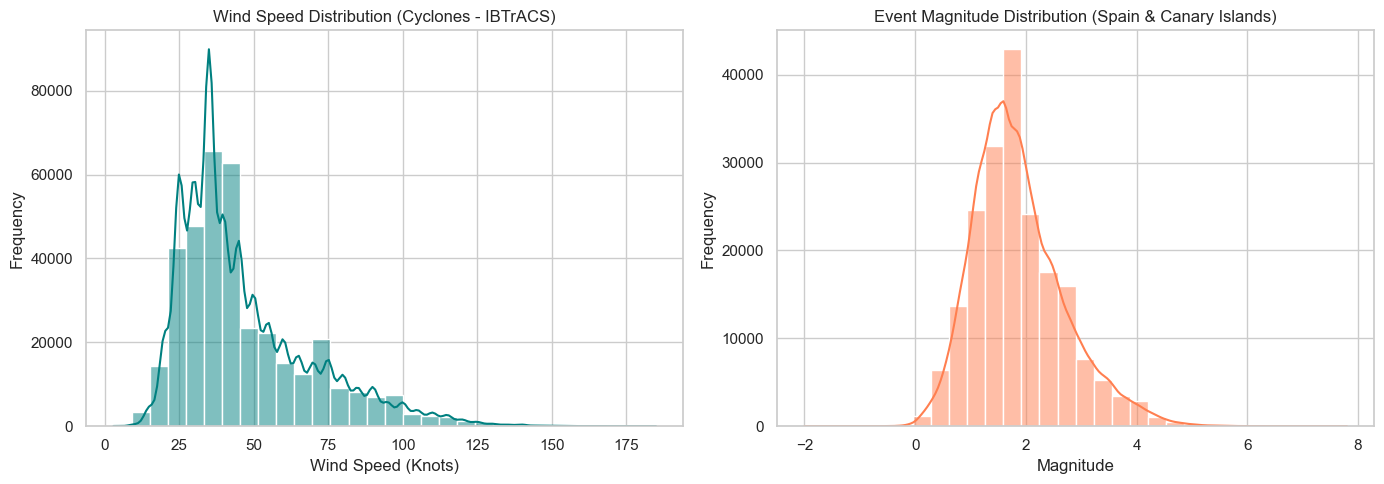

🖼️ Chart successfully saved to 'outputs/figures/distribucion_eventos.png'


In [12]:
# ------------------------------------------------------
# 5. EXPLORATORY DATA ANALYSIS (EDA) - DISTRIBUTIONS
# ------------------------------------------------------

os.makedirs('../outputs/figures', exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Wind Speed Distribution (Cyclones - IBTrACS)
sns.histplot(
    df_ciclones['wind'].dropna(),
    kde=True,
    ax=axes[0],
    color='teal',
    bins=30
)

axes[0].set_title('Wind Speed Distribution (Cyclones - IBTrACS)')
axes[0].set_xlabel('Wind Speed (Knots)')
axes[0].set_ylabel('Frequency')


# Plot 2: Event Magnitude Distribution (Spain & Canary Islands)
sns.histplot(
    df_espana['magnitude'].dropna(),
    kde=True,
    ax=axes[1],
    color='coral',
    bins=30
)

axes[1].set_title('Event Magnitude Distribution (Spain & Canary Islands)')
axes[1].set_xlabel('Magnitude')
axes[1].set_ylabel('Frequency')


plt.tight_layout()
plt.savefig('../outputs/figures/distribucion_eventos.png', dpi=300)
plt.show()

print("🖼️ Chart successfully saved to 'outputs/figures/distribucion_eventos.png'")

In [13]:
# ------------------------------------------------------
# 6. EXPORT PROCESSED DATASETS
# ------------------------------------------------------

os.makedirs('../data/processed', exist_ok=True)

df_ciclones.to_csv('../data/processed/ciclones_clean.csv', index=False)
df_volcanes.to_csv('../data/processed/volcanes_clean.csv', index=False)
df_espana.to_csv('../data/processed/espana_clean.csv', index=False)

print("💾 Processed datasets exported successfully to 'data/processed/'!")
print(" - data/processed/ciclones_clean.csv")
print(" - data/processed/volcanes_clean.csv")
print(" - data/processed/espana_clean.csv")

💾 Processed datasets exported successfully to 'data/processed/'!
 - data/processed/ciclones_clean.csv
 - data/processed/volcanes_clean.csv
 - data/processed/espana_clean.csv


In [14]:
# ------------------------------------------------------
# CHECK - Final IGN dataset structure
# ------------------------------------------------------

print(df_espana.shape)
print(df_espana.columns.tolist())

(203211, 11)
['event_id', 'Fecha', 'Hora', 'lat', 'lon', 'depth_km', 'Inten.', 'magnitude', 'mag_type', 'place', 'timestamp']


In [15]:
# ------------------------------------------------------
# FINAL CHECK - IGN CLEAN DATASET
# ------------------------------------------------------

print(df_espana.shape)

print("\n--- Data types ---")
print(df_espana.dtypes)

print("\n--- Missing values (%) ---")
print(
    (df_espana.isnull().sum() / len(df_espana) * 100)
    .round(2)
)

(203211, 11)

--- Data types ---
event_id             object
Fecha        datetime64[ns]
Hora                 object
lat                 float64
lon                 float64
depth_km            float64
Inten.               object
magnitude           float64
mag_type             object
place                object
timestamp    datetime64[ns]
dtype: object

--- Missing values (%) ---
event_id     0.00
Fecha        0.00
Hora         0.00
lat          0.00
lon          0.00
depth_km     0.00
Inten.       0.00
magnitude    1.86
mag_type     0.00
place        0.00
timestamp    0.00
dtype: float64


---
## 🎯 Conclusions & Handoff to Feature Engineering (Person 3)

1. **Standardized Spatial and Temporal Features:**
   
   All three datasets have been cleaned and standardized with consistent spatial coordinates (`lat`, `lon`), temporal information (`timestamp` where applicable), and hazard-specific intensity attributes such as `wind`, `magnitude`, `pressure`, and `elevation`.

2. **Ready for Spatial Aggregation:**

   The processed datasets exported to `data/processed/` are ready for the Feature Engineering stage, including **H3 Hexagonal Spatial Indexing** and the calculation of spatial hazard density metrics for risk modelling.

In [16]:
print(df_espana_raw[df_espana_raw["Longitud"] < -180][["Latitud","Longitud"]].head(20))


      Latitud  Longitud
121   425.000  -200.000
2112  374.167  -190.167
2140  380.000  -190.000
2739  375.000  -195.000
4922  291.600  -187.010
5213  291.600  -187.010
5217  288.300  -185.810
5265  358.383  -181.050
5550  307.130  -180.320
5720  276.990  -181.060
5918  374.800  -180.900
7231  276.860  -181.330
7235  379.350  -182.017
7326  275.170  -199.310
7364  277.150  -182.460
7365  277.000  -182.000
8488  273.980  -185.860
9425  277.220  -181.500
9433  277.420  -181.130
9545  277.710  -180.320
